# Dairy_DataVisualization2 — milk, plants, marketing-order boundaries, product utilization

Builds the marketing-area county list from the 7 CFR extract, then renders
`outputs/Dairy_DataVisualization2.png` from the processed county milk data (from
`Dairy_data_cleaning.ipynb`), plant lists, and the 2025 class-utilization shares.

In [5]:
# Locate the repository root (works whether Jupyter starts in the root or in code/)
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "raw").exists():
    ROOT = ROOT.parent
assert (ROOT / "raw").exists(), f"repository root not found from {Path.cwd()}"
print("repository root:", ROOT)

<class 'AssertionError'>: repository root not found from /drive/notebooks

## Shared map helpers (projection, geometry, marker fan-out, styles)

In [1]:
RAW = ROOT / "raw"
PROC = ROOT / "processed"
OUT = ROOT / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

from pathlib import Path
import textwrap
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

RAW, PROC, OUT = ROOT / "raw", ROOT / "processed", ROOT / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

UM, NE = ["MN", "WI", "MI"], ["NY", "VT", "PA"]
SFIPS = {"MN": "27", "WI": "55", "MI": "26", "NY": "36", "VT": "50", "PA": "42"}
ALBERS = "EPSG:5070"

plt.rcParams.update({"font.family": "DejaVu Sans",
                     "figure.facecolor": "white", "savefig.facecolor": "white"})
INK, SOFT = "#1a1a1a", "#555555"
BORDER, STATE_EDGE, NODATA = "#ffffff", "#7a7a7a", "#ececec"


def load_geo():
    g = gpd.read_file(RAW / "us_counties.json")[["id", "geometry"]].rename(columns={"id": "fips"})
    g["fips"] = g["fips"].astype(str).str.zfill(5)
    g["st"] = g["fips"].str[:2]
    return g.to_crs(ALBERS)


def region_frames(g):
    out = {}
    for name, states in (("Upper Midwest", UM), ("Northeast", NE)):
        codes = [SFIPS[s] for s in states]
        sub = g[g.st.isin(codes)].copy()
        out[name] = (sub, sub.dissolve(by="st"))
    return out


def fan_points(pts, land, R=9500):
    from shapely.geometry import Point
    pts["x"], pts["y"] = pts.geometry.x, pts.geometry.y
    for fips, gidx in pts.groupby("county_fips").groups.items():
        k = len(gidx)
        if k <= 1:
            continue
        x0 = pts.loc[gidx, "geometry"].x.values
        y0 = pts.loc[gidx, "geometry"].y.values
        for base in (np.pi / 4, 3 * np.pi / 4, 5 * np.pi / 4, 7 * np.pi / 4, 0.0):
            ang = np.linspace(0, 2 * np.pi, k, endpoint=False) + base
            xs, ys = x0 + R * np.cos(ang), y0 + R * np.sin(ang)
            if all(land.contains(Point(x, y)) for x, y in zip(xs, ys)):
                break
        pts.loc[gidx, "x"], pts.loc[gidx, "y"] = xs, ys

#This section above ensures that plant symbols in the same county do not overlap.


def panel_frame(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")


def title_block(fig, title, subtitle):
    fig.text(0.5, 0.965, title, ha="center", va="top",
             fontsize=21, fontweight="bold", color=INK)
    fig.text(0.5, 0.918, subtitle, ha="center", va="top", fontsize=12.5, color=SOFT)


def caption(fig, text, width=175):
    fig.text(0.03, 0.012, "\n".join(textwrap.wrap(text, width=width)),
             ha="left", va="bottom", fontsize=8.6, color=SOFT, linespacing=1.45)

#This section sets up the environment for creating visualization 2, such as defining the regions and the visual styles to be used in the map, loading geographical units, and helps with map formatting.

<class 'NameError'>: name 'ROOT' is not defined

## Build the marketing-area county list from the 7 CFR definitions

In [4]:
# 7 CFR 1030.2 (FMMO 30) and 1001.2 (FMMO 1) define each order's marketing area as county lists.
# match county names to Census geometry, save processed/fmmo_marketing_areas.csv.

import re as _re
import pandas as _pd

_gj = gpd.read_file(RAW / "us_counties.json")[["id", "STATE", "NAME"]]
_gj.columns = ["fips", "stfips", "name"]
_SF = {"MN": "27", "WI": "55", "MI": "26", "NY": "36", "VT": "50", "PA": "42"}

def _norm(n):
    return _re.sub(r"[^a-z]", "", str(n).lower())

_rows = []
for _ln in open(RAW / "fmmo_marketing_areas_cfr.txt"):
    if _ln.startswith("#") or not _ln.strip():
        continue
    _order, _st, _rule, _clist = _ln.strip().split("|")
    _wanted = {_norm(c) for c in _clist.split(";") if c}
    _sub = _gj[_gj.stfips == _SF[_st]]
    if _rule == "all_except":
        _sel = _sub[~_sub.name.map(_norm).isin(_wanted)]
        _missing = _wanted - set(_sub.name.map(_norm))
    else:
        _sel = _sub[_sub.name.map(_norm).isin(_wanted)]
        _missing = _wanted - set(_sel.name.map(_norm))
    assert not _missing, f"unmatched county names {_order} {_st}: {_missing}"
    for _, _r in _sel.iterrows():
        _rows.append(dict(order=int(_order), state=_st, fips=_r["fips"], county=_r["name"]))

_areas = _pd.DataFrame(_rows)
_areas.to_csv(PROC / "fmmo_marketing_areas.csv", index=False)
print(_areas.groupby(["order", "state"]).size().to_string())
print("marketing-area counties saved:", len(_areas))


#In this section, we match the county names to the market area definitions of FMMO 30 and FMMO 1 and saves the list of the marketing area boundaries.

<class 'NameError'>: name 'gpd' is not defined

## Build the visualization

In [ ]:
from pathlib import Path
import textwrap
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch

warnings.filterwarnings("ignore")


PROC, OUT = ROOT / "processed", ROOT / "outputs"
NODATA = "#D8DAE6"

CLS = [("I", "Fluid milk", "#173F5F"),
       ("II", "Soft products", "#3E6FA3"),
       ("III", "Cheese & whey", "#7FAECB"),
       ("IV", "Butter & powder", "#CFE2EF")]
BOUND_RED = "#D55E00"  
BOUND_BLACK = "#111111"

#This section above defines the milk use classes and the colors used in the visualization to show how milk has been utilized within the two FMMOs.

def load_points(fname, ptype):
    df = pd.read_csv(PROC / fname)
    df = df[df["on_dec_map"] == True].copy()
    df["ptype"] = ptype
    return df
#This reads the processed December plant list and adds a label identifying whether its records are supply or distributing plants.


def area_boundaries(g):
    areas = pd.read_csv(PROC / "fmmo_marketing_areas.csv", dtype={"fips": str})
    out = {}
    for order in (30, 1):
        fips = set(areas.loc[areas.order == order, "fips"].str.zfill(5))
        out[order] = g[g.fips.isin(fips)].dissolve()
    return out
#This matches the marketing area counties in the file built earlier to the county map and prepares them for the boundary shape to distinguish the two different FMMOs on the visualization.

LABEL_DARK = {"I": "#0072B2", "II": "#2c88bf", "III": "#b57b00", "IV": "#8a8412"}


def mini_bar(fig, rect, shares, label=None):
    ia = fig.add_axes(rect)
    ia.set_facecolor("none")
    left = 0.0
    for (code, name, color), v in zip(CLS, shares):
        ia.barh(0, v, left=left, height=1.0, color=color, edgecolor="white", linewidth=1.4)
        cx = left + v / 2
        lum = sum(w * int(color[i:i+2], 16) / 255
                  for w, i in ((0.2126, 1), (0.7152, 3), (0.0722, 5)))
        if v >= 7:
            ia.text(cx, 0, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color=("white" if lum < 0.45 else INK))
        else:
            # sliver: small label just below its segment, no tick
            ia.text(cx, -0.78, f"{v:.0f}%", ha="center", va="top",
                    fontsize=7.5, color=SOFT, clip_on=False)
        left += v
    ia.set_xlim(0, 100)
    ia.set_ylim(-0.62, 0.62)
    ia.set_xticks([])
    ia.set_yticks([])
    for sp in ia.spines.values():
        sp.set_visible(False)
    ia.set_title(label, fontsize=9.5, color=INK, pad=4)
    return ia
#This section builds the bars which show the annual milk use among the two FMMOs. It gives details about how to format it, to put percentages within the bar.


def callout(fig, ax_map, inset, target_xy):
    cp = ConnectionPatch(xyA=(0.5, 1.55), coordsA=inset.transAxes,
                         xyB=target_xy, coordsB=ax_map.transData,
                         color="#888888", linewidth=1.0, zorder=4)
    fig.add_artist(cp)
#This draws the grey line connecting the bars to the FMMO on the map.


def main(boundary_color=BOUND_RED, outname="Dairy_DataVisualization2.png", bars="strip"):
    g = load_geo()
    regions = region_frames(g)
    bounds = area_boundaries(g)

    milk = pd.read_csv(PROC / "county_total_dec2025.csv")
    milk["fips"] = milk["geo_fips"].astype(int).astype(str).str.zfill(5)
    milk["milk_m"] = milk["total_milk_pounds"] / 1e6
    milk = milk[["fips", "milk_m"]]

    util = pd.read_csv(PROC / "class_utilization_2025.csv").set_index("order")
    shares = {o: [util.loc[o, f"ann_{c}"] for c, _, _ in CLS] for o in (30, 1)}

    plants = pd.concat([load_points("supply_plants_dec2025.csv", "supply"),
                        load_points("distributing_plants_dec2025.csv", "distributing")],
                       ignore_index=True)
    pts = gpd.GeoDataFrame(plants, geometry=gpd.points_from_xy(plants.lon, plants.lat),
                           crs="EPSG:4326").to_crs(ALBERS)
    fan_points(pts, land=g.geometry.union_all())

    norm = LogNorm(vmin=0.03, vmax=milk["milk_m"].max())
    # brighter sequential ramp, same rule: lighter = less milk, darker = more (log scale)
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list(
        "milk_green", ["#FCFDE0", "#CFEEA8", "#7BD27C", "#2EA858", "#128046", "#0A4A30"])

    figsize, top, bottom = (15.5, 9.8), 0.862, 0.265
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.subplots_adjust(left=0.01, right=0.99, top=top, bottom=bottom,
                        wspace=(0.50 if bars == "center" else 0.04))

    panel_order = {"Upper Midwest": 30, "Northeast": 1}
    # figure coordinates: flanking strip, or stacked pair in the center gutter
    if bars == "center":
        bar_rect = {"Upper Midwest": (0.405, 0.560, 0.190, 0.036),
                    "Northeast": (0.405, 0.445, 0.190, 0.036)}
    else:
        bar_rect = {"Upper Midwest": (0.030, 0.201, 0.245, 0.044),
                    "Northeast": (0.725, 0.201, 0.245, 0.044)}
    bar_label = {30: "FMMO 30 milk use shares, 2025",
                 1: "FMMO 1 milk use shares, 2025"}
    # call-out anchor points inside each outlined area (lon, lat -> Albers)
    anchor_ll = {30: (-90.2, 44.9), 1: (-75.2, 43.1)}
    anchors = gpd.GeoSeries(gpd.points_from_xy(*zip(*anchor_ll.values())),
                            crs="EPSG:4326").to_crs(ALBERS)
    anchor_xy = dict(zip(anchor_ll.keys(), [(p.x, p.y) for p in anchors]))

    for ax, (rname, (cty, states_geom)) in zip(axes, regions.items()):
        m = cty.merge(milk, on="fips", how="left")
        m[m["milk_m"].isna()].plot(ax=ax, color=NODATA, edgecolor=BORDER, linewidth=0.35)
        m[m["milk_m"].notna()].plot(ax=ax, column="milk_m", cmap=cmap, norm=norm,
                                    edgecolor=BORDER, linewidth=0.35)
        states_geom.boundary.plot(ax=ax, color=STATE_EDGE, linewidth=1.0)

        order = panel_order[rname]
        bounds[order].boundary.plot(ax=ax, color=boundary_color, linewidth=2.1, zorder=4)

        rp = pts[pts.region == rname]
        sup, dis = rp[rp.ptype == "supply"], rp[rp.ptype == "distributing"]
        ax.scatter(dis["x"], dis["y"], s=54, marker="o",
                   facecolor="#ffffff", edgecolor="#111111", linewidth=1.3, zorder=5)
        ax.scatter(sup["x"], sup["y"], s=72, marker="^",
                   facecolor="#111111", edgecolor="#ffffff", linewidth=1.1, zorder=6)
        panel_frame(ax)

        tot = m["milk_m"].sum() / 1000
        panel_cx = 0.5 * (ax.get_position().x0 + ax.get_position().x1)
        panel_states = {"Upper Midwest": "MI, MN, WI", "Northeast": "NY, PA, VT"}[rname]
        fig.text(panel_cx, 0.916, f"{rname} ({panel_states})",
                 ha="center", va="top", fontsize=13, fontweight="bold", color=INK)
        fig.text(panel_cx, 0.891,
                 f"{len(sup)} manufacturing plants · {len(dis)} distributing plants · {tot:.1f}B lbs milk produced",
                 ha="center", va="top", fontsize=11, color=INK)

        ia = mini_bar(fig, bar_rect[rname], shares[order], bar_label[order])
        if bars != "center":
            callout(fig, ax, ia, anchor_xy[order])

    fig.text(0.5, 0.972, "Milk Production, Processing, and Diversity",
             ha="center", va="top", fontsize=20, fontweight="bold", color=INK)

    # bottom zone: colorbar, then two legend rows
    cax_y = 0.190
    cax = fig.add_axes([0.315, cax_y, 0.37, 0.018])
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.set_label("Producer milk (million lbs, log scale)",
                 fontsize=9.5, color=SOFT, labelpad=5)
    cb.ax.xaxis.set_label_position("top")
    cb.ax.tick_params(labelsize=8.5, colors=SOFT)
    cb.outline.set_visible(False)

    row1 = [Line2D([], [], marker="^", linestyle="", markersize=10.5,
                   markerfacecolor="#111111", markeredgecolor="white",
                   label="Manufacturing plants"),
            Line2D([], [], marker="o", linestyle="", markersize=9,
                   markerfacecolor="white", markeredgecolor="#111111",
                   label="Distributing plants"),
            Line2D([], [], color=boundary_color, linewidth=2.1,
                   label="Federal Milk Marketing Order boundary"),
            mpatches.Patch(facecolor=NODATA, label="No milk reported")]
    leg1_y = 0.075
    fig.legend(handles=row1, loc="lower center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, leg1_y), fontsize=10, handletextpad=0.5,
               columnspacing=1.5)

    row2 = [mpatches.Patch(facecolor=c, edgecolor="white", label=f"{l} (Class {k})")
            for k, l, c in CLS]
    leg2_y = 0.037
    fig.legend(handles=row2, loc="lower center", ncol=4, frameon=False,
               bbox_to_anchor=(0.5, leg2_y), fontsize=10, handletextpad=0.5,
               columnspacing=1.5)

    fig.savefig(OUT / outname, dpi=220)
    plt.close(fig)
    print(outname, "written")

#This section creates Visualization 2 by loading the county boundaries, milk production data, plant location data, FMMO boundaries, and the milk use shares.
#It creates separate maps for the two different regions, 
#It puts the colors on the counties based on how much milk has been produced, 
#It adds the symbols (triangles and circles) to identify plants whether supply (or manufacturing) or distributing plant.
#It adds the bars showing the milk use shares for the different FMMOs.
#It also adds titles and legends.

In [7]:
main(boundary_color=BOUND_RED, outname="Dairy_DataVisualization2.png")

#This section draws the FMMO boundary on the map and exports visualization 2 as PNG file.

<class 'NameError'>: name 'load_geo' is not defined

## Display the result

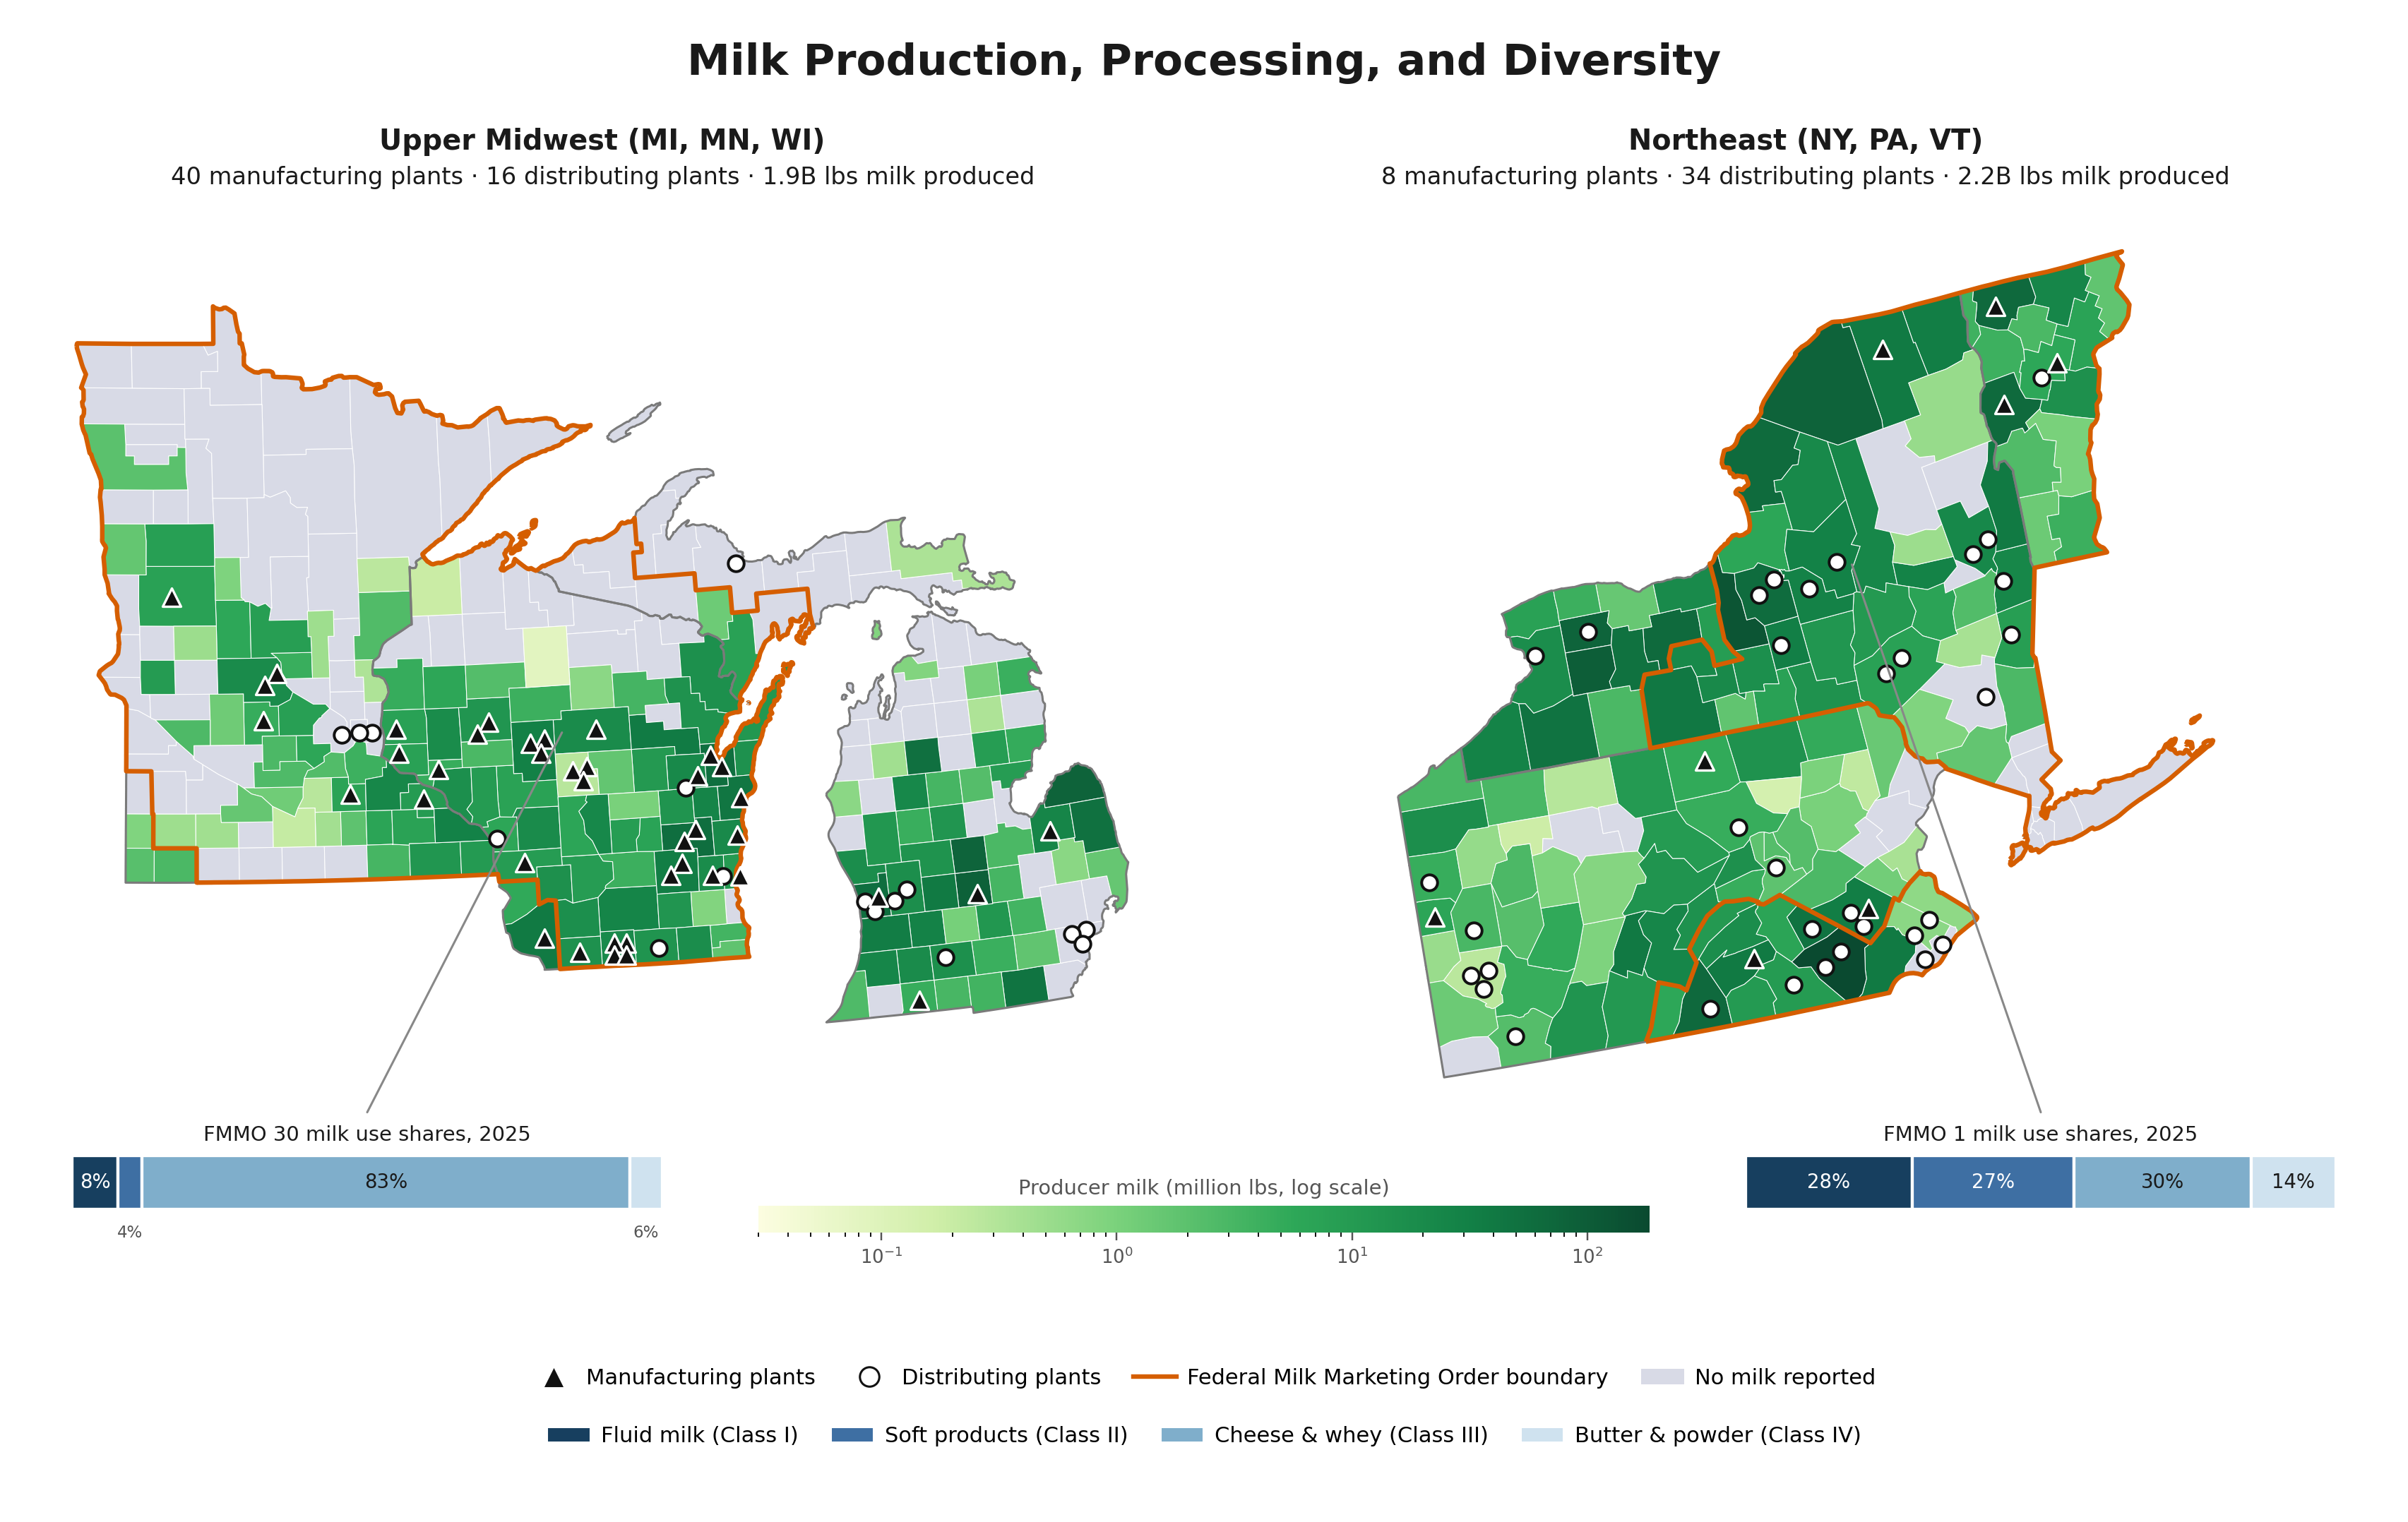

In [50]:
from IPython.display import Image, display
display(Image(str(OUT / "Dairy_DataVisualization2.png"), width=1000))

#This provides a nice preview of the visualization.